# Spatial Wavelet Transform - Kronecker Matrix Transform 
February 19, 2024

Transform the per image matrix transforms to flattened matrices so we can operate against flattened images.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [4]:
chromatin_model.create_deconvolution_bins()

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [5]:
G = chromatin_model.G

In [6]:
image_shape = chromatin_model.deconv_hist_unflattened.shape[1:]
image_shape

(16, 50)

In [9]:
import pywt
from src.wavelets_2d_linalg import create_kron_wavelet2d_convolution_matrices, decompose_flattened_kron_coeffs, \
    reconstruct_flattened_kron_coeffs

wavelet = pywt.Wavelet('bior4.4')
decomp_mats, reconst_mats = create_kron_wavelet2d_convolution_matrices(wavelet, image_shape)


In [11]:
coeffs = decompose_flattened_kron_coeffs(G, decomp_mats)
reconstructed = reconstruct_flattened_kron_coeffs(coeffs, reconst_mats)

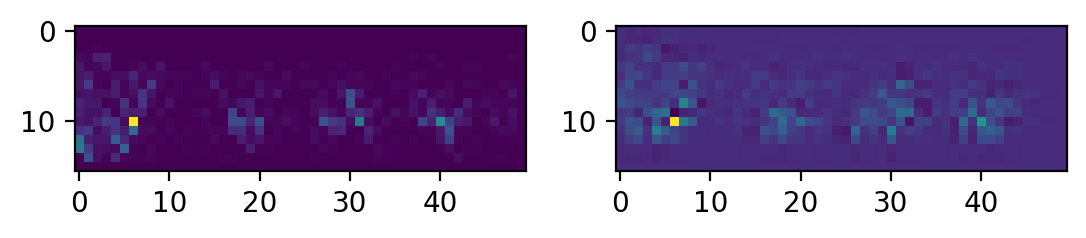

In [14]:
plt.subplot(1, 2, 1)
plt.imshow(G[1].reshape(image_shape))
plt.subplot(1, 2, 2)
plt.imshow(reconstructed[1].reshape(image_shape))

In [17]:
from src.timer import Timer

timer = Timer()

for i in range(1000):
    coeffs = decompose_flattened_kron_coeffs(G, decomp_mats)
    reconstructed = reconstruct_flattened_kron_coeffs(coeffs, reconst_mats)

timer.get_time()

'00:00:04.10'